In [19]:
# Core data manipulation and numerical operations
import pandas as pd  # <- This is for working with data tables
import numpy as np   # <- This is for mathematical operations

# Visualization libraries
import matplotlib.pyplot as plt  # <- For creating plots
import seaborn as sns            # <- Makes prettier plots

# Machine learning tools from scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Experiment tracking and hyperparameter tuning
import mlflow              # <- Tracks all our experiments
import mlflow.sklearn      # <- Special MLflow tools for sklearn
import optuna              # <- Automatically finds best parameters

# Suppress warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

# IMPORTANT: Set random seed for reproducibility
np.random.seed(42)

print(":white_check_mark: All packages loaded successfully!")

:white_check_mark: All packages loaded successfully!


In [20]:
# ==========================================
# EXTRACT PHASE - Getting the Data
# ==========================================

print("=" * 50)
print("PHASE 1: EXTRACTING DATA")
print("=" * 50)

# Load wine quality dataset from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

# Read the CSV file
# Notice the sep=';' - this file uses semicolons instead of commas!
df = pd.read_csv(url, sep=';')

print(f"\n:bar_chart: Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

PHASE 1: EXTRACTING DATA

:bar_chart: Dataset loaded successfully!
Shape: 1599 rows × 12 columns


In [21]:
print(df.head()) # Display the first few rows of the dataset

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 


:mag: CHECK 5: Understanding our target variable (quality)...


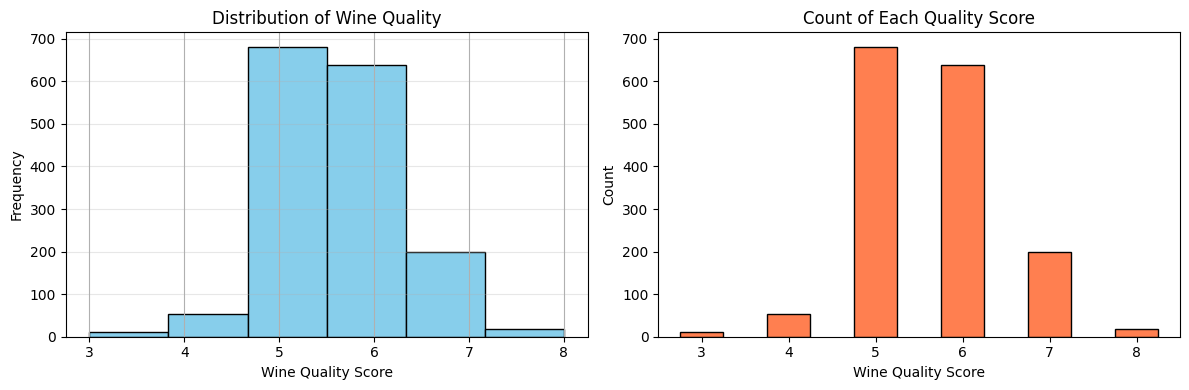


Quality statistics:
  Minimum quality: 3
  Maximum quality: 8
  Average quality: 5.64
  Most common quality: 5


In [22]:
# Check 5: Visualize the target variable
print("\n:mag: CHECK 5: Understanding our target variable (quality)...")

# Create a figure with two subplots
plt.figure(figsize=(12, 4))

# Histogram
plt.subplot(1, 2, 1)
df['quality'].hist(bins=6, edgecolor='black', color='skyblue')
plt.xlabel('Wine Quality Score')
plt.ylabel('Frequency')
plt.title('Distribution of Wine Quality')
plt.grid(axis='y', alpha=0.3)

# Value counts bar plot
plt.subplot(1, 2, 2)
quality_counts = df['quality'].value_counts().sort_index()
quality_counts.plot(kind='bar', color='coral', edgecolor='black')
plt.xlabel('Wine Quality Score')
plt.ylabel('Count')
plt.title('Count of Each Quality Score')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(f"\nQuality statistics:")
print(f"  Minimum quality: {df['quality'].min()}")
print(f"  Maximum quality: {df['quality'].max()}")
print(f"  Average quality: {df['quality'].mean():.2f}")
print(f"  Most common quality: {df['quality'].mode()[0]}")


Created new binary variable 'good_wine':
good_wine
1    855
0    744
Name: count, dtype: int64


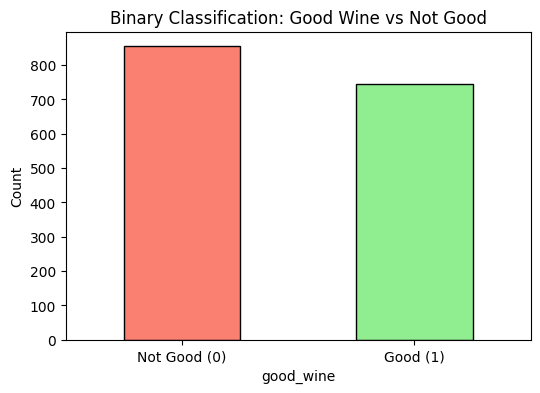

In [23]:
# Create a binary target variable for demonstration
# Let's say "good wine" is quality >= 6
df['good_wine'] = (df['quality'] >= 6).astype(int)

print("\nCreated new binary variable 'good_wine':")
print(df['good_wine'].value_counts())

# Visualize it
plt.figure(figsize=(6, 4))
df['good_wine'].value_counts().plot(kind='bar', color=['salmon', 'lightgreen'], 
                                     edgecolor='black')
plt.xticks([0, 1], ['Not Good (0)', 'Good (1)'], rotation=0)
plt.ylabel('Count')
plt.title('Binary Classification: Good Wine vs Not Good')
plt.show()


Correlation of each feature with quality:
quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


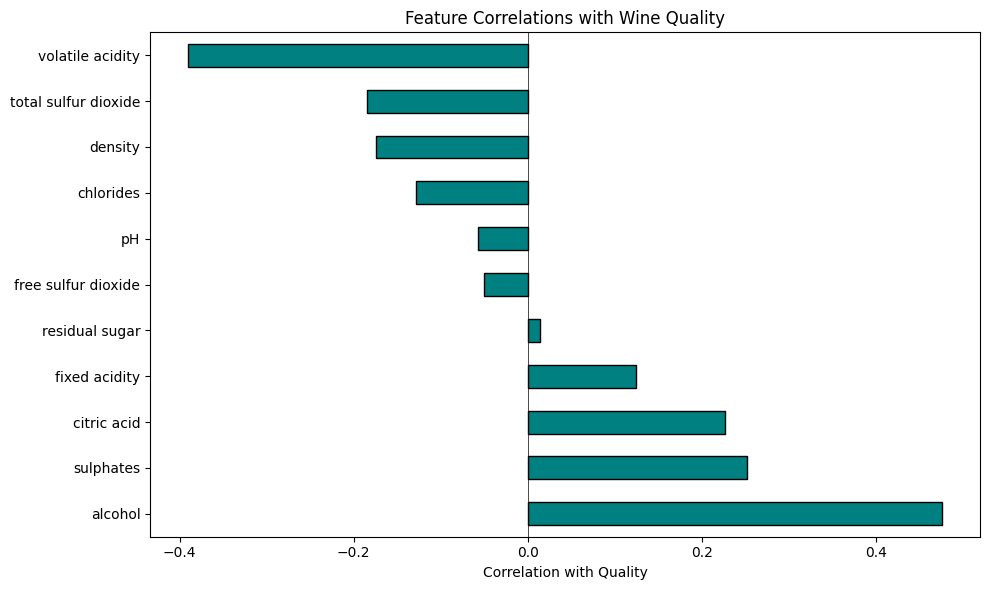

In [24]:
# Quick correlation check
print("\nCorrelation of each feature with quality:")
correlations = df.drop('good_wine', axis=1).corr()['quality'].sort_values(ascending=False)
print(correlations)

# Visualize top correlations
plt.figure(figsize=(10, 6))
correlations.drop('quality').plot(kind='barh', color='teal', edgecolor='black')
plt.xlabel('Correlation with Quality')
plt.title('Feature Correlations with Wine Quality')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

In [25]:
# ==========================================
# LOAD PHASE - Prepare for Modeling
# ==========================================

print("=" * 50)
print("PHASE 3: LOADING DATA FOR MODELING")
print("=" * 50)

# Separate features (X) from target (y)
# We'll drop both 'quality' and 'good_wine' from features
# and use 'quality' as our target

X = df.drop(['quality', 'good_wine'], axis=1)
y = df['quality']

print(f"\n Data prepared for modeling!")
print(f"Features (X) shape: {X.shape}")
print(f"  - {X.shape[0]} samples (wines)")
print(f"  - {X.shape[1]} features (measurements)")
print(f"\nTarget (y) shape: {y.shape}")
print(f"  - {y.shape[0]} values to predict")

print(f"\nFeature names:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i}. {col}")

print("\n" + "=" * 50)
print("ETL PHASE COMPLETE!")
print("=" * 50)

PHASE 3: LOADING DATA FOR MODELING

 Data prepared for modeling!
Features (X) shape: (1599, 11)
  - 1599 samples (wines)
  - 11 features (measurements)

Target (y) shape: (1599,)
  - 1599 values to predict

Feature names:
  1. fixed acidity
  2. volatile acidity
  3. citric acid
  4. residual sugar
  5. chlorides
  6. free sulfur dioxide
  7. total sulfur dioxide
  8. density
  9. pH
  10. sulphates
  11. alcohol

ETL PHASE COMPLETE!


In [26]:
# ==========================================
# VALIDATION STRATEGY: Train/Val/Test Split
# ==========================================

print("=" * 50)
print("CREATING TRAIN/VALIDATION/TEST SPLITS")
print("=" * 50)

# First, we'll split off our test set (15% of data)
# The remaining 85% will be split into train and validation

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.15,      # 15% for testing
    random_state=42      # For reproducibility
)

print(f"\n Step 1: Split off test set")
print(f"  Remaining data: {len(X_temp)} samples")
print(f"  Test set: {len(X_test)} samples")

# Now split the remaining 85% into train (70% of original) and validation (15% of original)
# We need validation to be 15% of original, which is 15/85 ≈ 0.176 of the remaining data

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,     # This gives us 15% of original data
    random_state=42
)

print(f"\nStep 2: Split remaining into train and validation")
print(f"  Training set: {len(X_train)} samples")
print(f"  Validation set: {len(X_val)} samples")

# Verify the split percentages
total = len(X)
print(f"\n" + "=" * 50)
print("FINAL SPLIT VERIFICATION:")
print(f"  Total samples: {total}")
print(f"  Training: {len(X_train)} ({len(X_train)/total*100:.1f}%)")
print(f"  Validation: {len(X_val)} ({len(X_val)/total*100:.1f}%)")
print(f"  Test: {len(X_test)} ({len(X_test)/total*100:.1f}%)")
print("=" * 50)

CREATING TRAIN/VALIDATION/TEST SPLITS

 Step 1: Split off test set
  Remaining data: 1359 samples
  Test set: 240 samples

Step 2: Split remaining into train and validation
  Training set: 1119 samples
  Validation set: 240 samples

FINAL SPLIT VERIFICATION:
  Total samples: 1599
  Training: 1119 (70.0%)
  Validation: 240 (15.0%)
  Test: 240 (15.0%)


In [27]:
# ==========================================
# CROSS-VALIDATION DEMONSTRATION
# ==========================================

print("\n" + "=" * 50)
print("DEMONSTRATING CROSS-VALIDATION")
print("=" * 50)

# Import Random Forest
from sklearn.ensemble import RandomForestRegressor

# Create a simple model
model = RandomForestRegressor(
    n_estimators=50,    # Number of trees
    random_state=42     # For reproducibility
)

print("\nTraining model with 5-fold cross-validation...")
print("This means we'll train and evaluate 5 times on different data splits.")

# Perform 5-fold cross-validation
# Note: we use NEGATIVE mean squared error because sklearn's cross_val_score
# assumes "higher is better", but for errors, lower is better
cv_scores = cross_val_score(
    model, 
    X_train, 
    y_train, 
    cv=5,                              # 5 folds
    scoring='neg_mean_squared_error'   # Our metric
)

# Convert to RMSE (Root Mean Squared Error)
# Remember: negative because sklearn convention
cv_rmse = np.sqrt(-cv_scores)

print("\n:bar_chart: Cross-Validation Results:")
print(f"  Fold 1 RMSE: {cv_rmse[0]:.4f}")
print(f"  Fold 2 RMSE: {cv_rmse[1]:.4f}")
print(f"  Fold 3 RMSE: {cv_rmse[2]:.4f}")
print(f"  Fold 4 RMSE: {cv_rmse[3]:.4f}")
print(f"  Fold 5 RMSE: {cv_rmse[4]:.4f}")
print(f"\n  Mean RMSE: {cv_rmse.mean():.4f}")
print(f"  Std Dev: {cv_rmse.std():.4f}")

print("\n:bulb: Interpretation:")
print(f"  On average, our predictions are off by {cv_rmse.mean():.2f} quality points")
print(f"  (Remember: quality ranges from 3-8)")


DEMONSTRATING CROSS-VALIDATION

Training model with 5-fold cross-validation...
This means we'll train and evaluate 5 times on different data splits.

:bar_chart: Cross-Validation Results:
  Fold 1 RMSE: 0.5246
  Fold 2 RMSE: 0.6326
  Fold 3 RMSE: 0.5833
  Fold 4 RMSE: 0.5898
  Fold 5 RMSE: 0.6615

  Mean RMSE: 0.5984
  Std Dev: 0.0467

:bulb: Interpretation:
  On average, our predictions are off by 0.60 quality points
  (Remember: quality ranges from 3-8)


In [28]:
# ==========================================
# FEATURE ENGINEERING
# ==========================================

print("=" * 50)
print("FEATURE ENGINEERING - CREATING BETTER FEATURES")
print("=" * 50)

def engineer_features(X_df):
    """
    Create new features from existing ones
    This function will be applied to train, validation, and test sets
    """
    # IMPORTANT: Always work with a copy!
    X_new = X_df.copy()
    
    print("\n:wrench: Creating new features...")
    
    # ======================
    # 1. RATIO FEATURES
    # ======================
    print("  1. Creating ratio features...")
    # Alcohol to sugar ratio - maybe high alcohol + low sugar = quality?
    X_new['alcohol_sugar_ratio'] = X_new['alcohol'] / (X_new['residual sugar'] + 1)
    # Adding 1 to avoid division by zero
    
    # Ratio of fixed to volatile acidity
    X_new['acid_ratio'] = X_new['fixed acidity'] / (X_new['volatile acidity'] + 0.1)
    
    # ======================
    # 2. POLYNOMIAL FEATURES
    # ======================
    print("  2. Creating polynomial features...")
    # Sometimes relationships are non-linear - squaring helps capture this
    X_new['alcohol_squared'] = X_new['alcohol'] ** 2
    X_new['sulphates_squared'] = X_new['sulphates'] ** 2
    
    # ======================
    # 3. BINNING (DISCRETIZATION)
    # ======================
    print("  3. Creating binned features...")
    # Convert continuous variable into categories
    # Low alcohol (< 9.5), Medium (9.5-11), High (> 11)
    X_new['alcohol_level'] = pd.cut(
        X_new['alcohol'], 
        bins=[0, 9.5, 11, 15],  # Bin edges
        labels=[0, 1, 2]         # Low, Medium, High
    )
    X_new['alcohol_level'] = X_new['alcohol_level'].astype(float)
    
    # ======================
    # 4. LOG TRANSFORMATIONS
    # ======================
    print("  4. Creating log-transformed features...")
    # Log transformation helps with skewed distributions
    # np.log1p is log(1 + x) - safer than regular log
    X_new['log_residual_sugar'] = np.log1p(X_new['residual sugar'])
    
    # ======================
    # 5. INTERACTION FEATURES
    # ======================
    print("  5. Creating interaction features...")
    # Product of two features - captures their combined effect
    X_new['alcohol_sulphates'] = X_new['alcohol'] * X_new['sulphates']
    
    return X_new

# Show before and after
print(f"\nBefore feature engineering:")
print(f"  Number of features: {X_train.shape[1]}")
print(f"  Feature names: {list(X_train.columns)}")

FEATURE ENGINEERING - CREATING BETTER FEATURES

Before feature engineering:
  Number of features: 11
  Feature names: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [29]:
# Apply feature engineering to all three sets
X_train_eng = engineer_features(X_train)
X_val_eng = engineer_features(X_val)
X_test_eng = engineer_features(X_test)

print(f"\n:white_check_mark: Feature engineering complete!")
print(f"\nAfter feature engineering:")
print(f"  Number of features: {X_train_eng.shape[1]}")
print(f"  Original features: {X_train.shape[1]}")
print(f"  New features created: {X_train_eng.shape[1] - X_train.shape[1]}")

print(f"\nNew feature names:")
new_features = [col for col in X_train_eng.columns if col not in X_train.columns]
for i, feat in enumerate(new_features, 1):
    print(f"  {i}. {feat}")


:wrench: Creating new features...
  1. Creating ratio features...
  2. Creating polynomial features...
  3. Creating binned features...
  4. Creating log-transformed features...
  5. Creating interaction features...

:wrench: Creating new features...
  1. Creating ratio features...
  2. Creating polynomial features...
  3. Creating binned features...
  4. Creating log-transformed features...
  5. Creating interaction features...

:wrench: Creating new features...
  1. Creating ratio features...
  2. Creating polynomial features...
  3. Creating binned features...
  4. Creating log-transformed features...
  5. Creating interaction features...

:white_check_mark: Feature engineering complete!

After feature engineering:
  Number of features: 18
  Original features: 11
  New features created: 7

New feature names:
  1. alcohol_sugar_ratio
  2. acid_ratio
  3. alcohol_squared
  4. sulphates_squared
  5. alcohol_level
  6. log_residual_sugar
  7. alcohol_sulphates


In [30]:
# ==========================================
# FEATURE SCALING (THE CORRECT WAY)
# ==========================================

print("\n" + "=" * 50)
print("SCALING FEATURES CORRECTLY")
print("=" * 50)

# Create the scaler
scaler = StandardScaler()

# FIT on training data ONLY - this calculates mean and std
print("\nStep 1: Fitting scaler on TRAINING data...")
scaler.fit(X_train_eng)

# Now TRANSFORM all three sets using the SAME parameters
print("Step 2: Transforming all datasets with training statistics...")
X_train_scaled = scaler.transform(X_train_eng)
X_val_scaled = scaler.transform(X_val_eng)
X_test_scaled = scaler.transform(X_test_eng)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_eng.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val_eng.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_eng.columns)

print("\n:white_check_mark: Scaling complete!")

# Verify scaling worked
print("\n:bar_chart: Verification - Training set statistics after scaling:")
print("   Mean values (should be close to 0):")
print(f"   {X_train_scaled.mean().abs().max():.10f} (very close to 0 ✓)")
print("\n   Std deviation (should be close to 1):")
print(f"   {X_train_scaled.std().mean():.2f} (approximately 1 ✓)")

print("\n" + "=" * 50)
print("FEATURE ENGINEERING COMPLETE! :white_check_mark:")
print("=" * 50)


SCALING FEATURES CORRECTLY

Step 1: Fitting scaler on TRAINING data...
Step 2: Transforming all datasets with training statistics...

:white_check_mark: Scaling complete!

:bar_chart: Verification - Training set statistics after scaling:
   Mean values (should be close to 0):
   0.0000000000 (very close to 0 ✓)

   Std deviation (should be close to 1):
   1.00 (approximately 1 ✓)

FEATURE ENGINEERING COMPLETE! :white_check_mark:


In [31]:
# ==========================================
# EXPERIMENT TRACKING WITH MLFLOW
# ==========================================

print("=" * 50)
print("SETTING UP EXPERIMENT TRACKING")
print("=" * 50)

# Set the experiment name
mlflow.set_experiment("wine_quality_demo")

print("\n:white_check_mark: MLflow experiment created: 'wine_quality_demo'")
print("\n:bulb: After we run experiments, you can view them by:")
print("   1. Opening terminal")
print("   2. Running: mlflow ui")
print("   3. Visiting: http://localhost:5000 in your browser")

SETTING UP EXPERIMENT TRACKING

:white_check_mark: MLflow experiment created: 'wine_quality_demo'

:bulb: After we run experiments, you can view them by:
   1. Opening terminal
   2. Running: mlflow ui
   3. Visiting: http://localhost:5000 in your browser


In [32]:
def train_and_log_model(params, X_tr, y_tr, X_v, y_v, run_name):
    """
    Train a model and log everything to MLflow
    
    Parameters:
    - params: Dictionary of model hyperparameters
    - X_tr, y_tr: Training data
    - X_v, y_v: Validation data
    - run_name: Name for this experiment run
    """
    
    print(f"\n{'='*50}")
    print(f":microscope: EXPERIMENT: {run_name}")
    print(f"{'='*50}")
    
    # Start an MLflow run
    with mlflow.start_run(run_name=run_name):
        
        # 1. LOG PARAMETERS
        print("\n:one: Logging parameters...")
        mlflow.log_params(params)
        for key, value in params.items():
            print(f"   {key}: {value}")
        
        # 2. TRAIN MODEL
        print("\n:two: Training model...")
        model = RandomForestRegressor(**params)
        model.fit(X_tr, y_tr)
        print("   ✓ Model trained")
        
        # 3. MAKE PREDICTIONS
        print("\n:three: Making predictions...")
        train_pred = model.predict(X_tr)
        val_pred = model.predict(X_v)
        print("   ✓ Predictions generated")
        
        # 4. CALCULATE METRICS
        print("\n:four: Calculating metrics...")
        train_rmse = np.sqrt(mean_squared_error(y_tr, train_pred))
        val_rmse = np.sqrt(mean_squared_error(y_v, val_pred))
        train_r2 = r2_score(y_tr, train_pred)
        val_r2 = r2_score(y_v, val_pred)
        
        # 5. LOG METRICS
        print("\n:five: Logging metrics...")
        mlflow.log_metric("train_rmse", train_rmse)
        mlflow.log_metric("val_rmse", val_rmse)
        mlflow.log_metric("train_r2", train_r2)
        mlflow.log_metric("val_r2", val_r2)
        
        # 6. LOG MODEL
        print("\n:six: Logging model...")
        mlflow.sklearn.log_model(model, "model")
        
        # 7. DISPLAY RESULTS
        print("\n" + "=" * 50)
        print(":bar_chart: RESULTS:")
        print(f"   Training RMSE: {train_rmse:.4f} | R²: {train_r2:.4f}")
        print(f"   Validation RMSE: {val_rmse:.4f} | R²: {val_r2:.4f}")
        
        # Check for overfitting
        if train_rmse < val_rmse * 0.7:  # Arbitrary threshold
            print("\n   :warning:  Possible overfitting detected!")
            print(f"   (Training RMSE much lower than validation)")
        else:
            print("\n   ✓ Model generalizes well")
        
        print("=" * 50)
        
        return model, val_rmse

print("\n:white_check_mark: Helper function created!")


:white_check_mark: Helper function created!


In [33]:
# ==========================================
# EXPERIMENT 1: BASELINE MODEL
# ==========================================

print("\n\n" + ":star2:" * 25)
print("STARTING EXPERIMENT 1: BASELINE")
print(":star2:" * 25)

print("\n:memo: Strategy: Start with a simple, conservative model")
print("   - Few trees (faster training)")
print("   - Shallow trees (prevents overfitting)")

params_baseline = {
    'n_estimators': 50,      # Number of trees
    'max_depth': 5,          # Maximum depth of each tree
    'random_state': 42
}

model1, rmse1 = train_and_log_model(
    params_baseline,
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    "experiment_1_baseline"
)

print("\n:bulb: Baseline established! This is our starting point to improve upon.")



:star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2:
STARTING EXPERIMENT 1: BASELINE
:star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2:

:memo: Strategy: Start with a simple, conservative model
   - Few trees (faster training)
   - Shallow trees (prevents overfitting)

:microscope: EXPERIMENT: experiment_1_baseline

:one: Logging parameters...
   n_estimators: 50
   max_depth: 5
   random_state: 42

:two: Training model...


2025/11/25 20:36:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


   ✓ Model trained

:three: Making predictions...
   ✓ Predictions generated

:four: Calculating metrics...

:five: Logging metrics...

:six: Logging model...


2025/11/25 20:36:17 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



:bar_chart: RESULTS:
   Training RMSE: 0.5297 | R²: 0.5624
   Validation RMSE: 0.6681 | R²: 0.3435

   ✓ Model generalizes well

:bulb: Baseline established! This is our starting point to improve upon.


In [34]:
# ==========================================
# EXPERIMENT 2: MORE TREES
# ==========================================

print("\n\n" + ":star2:" * 25)
print("STARTING EXPERIMENT 2: MORE TREES")
print(":star2:" * 25)

print("\n:memo: Strategy: Use more trees for better predictions")
print("   - 200 trees instead of 50")
print("   - Same depth (keeping it fair)")

params_more_trees = {
    'n_estimators': 200,     # 4x more trees!
    'max_depth': 5,          # Same depth
    'random_state': 42
}

model2, rmse2 = train_and_log_model(
    params_more_trees,
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    "experiment_2_more_trees"
)

# Compare to baseline
print(f"\n:bar_chart: COMPARISON TO BASELINE:")
print(f"   Baseline RMSE: {rmse1:.4f}")
print(f"   More Trees RMSE: {rmse2:.4f}")
print(f"   Improvement: {((rmse1 - rmse2)/rmse1*100):.2f}%")



:star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2:
STARTING EXPERIMENT 2: MORE TREES
:star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2:

:memo: Strategy: Use more trees for better predictions
   - 200 trees instead of 50
   - Same depth (keeping it fair)

:microscope: EXPERIMENT: experiment_2_more_trees

:one: Logging parameters...
   n_estimators: 200
   max_depth: 5
   random_state: 42

:two: Training model...


2025/11/25 20:36:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


   ✓ Model trained

:three: Making predictions...
   ✓ Predictions generated

:four: Calculating metrics...

:five: Logging metrics...

:six: Logging model...


2025/11/25 20:36:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



:bar_chart: RESULTS:
   Training RMSE: 0.5263 | R²: 0.5680
   Validation RMSE: 0.6681 | R²: 0.3436

   ✓ Model generalizes well

:bar_chart: COMPARISON TO BASELINE:
   Baseline RMSE: 0.6681
   More Trees RMSE: 0.6681
   Improvement: 0.00%


In [35]:
# ==========================================
# EXPERIMENT 3: DEEPER TREES
# ==========================================

print("\n\n" + ":star2:" * 25)
print("STARTING EXPERIMENT 3: DEEPER TREES")
print(":star2:" * 25)

print("\n:memo: Strategy: Allow trees to be deeper for more complex patterns")
print("   - Depth of 15 instead of 5")
print("   - 100 trees (middle ground)")

params_deeper = {
    'n_estimators': 100,     # Middle ground
    'max_depth': 15,         # 3x deeper!
    'random_state': 42
}

model3, rmse3 = train_and_log_model(
    params_deeper,
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    "experiment_3_deeper_trees"
)

# Compare all three
print(f"\n:bar_chart: COMPARISON OF ALL EXPERIMENTS:")
print(f"   Experiment 1 (Baseline):    RMSE = {rmse1:.4f}")
print(f"   Experiment 2 (More Trees):  RMSE = {rmse2:.4f}")
print(f"   Experiment 3 (Deeper Trees): RMSE = {rmse3:.4f}")
print(f"\n   Best so far: Experiment {[rmse1, rmse2, rmse3].index(min([rmse1, rmse2, rmse3])) + 1}")



:star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2:
STARTING EXPERIMENT 3: DEEPER TREES
:star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2::star2:

:memo: Strategy: Allow trees to be deeper for more complex patterns
   - Depth of 15 instead of 5
   - 100 trees (middle ground)

:microscope: EXPERIMENT: experiment_3_deeper_trees

:one: Logging parameters...
   n_estimators: 100
   max_depth: 15
   random_state: 42

:two: Training model...


2025/11/25 20:36:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


   ✓ Model trained

:three: Making predictions...
   ✓ Predictions generated

:four: Calculating metrics...

:five: Logging metrics...

:six: Logging model...


2025/11/25 20:36:27 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



:bar_chart: RESULTS:
   Training RMSE: 0.2353 | R²: 0.9136
   Validation RMSE: 0.6388 | R²: 0.3998

   :warning:  Possible overfitting detected!
   (Training RMSE much lower than validation)

:bar_chart: COMPARISON OF ALL EXPERIMENTS:
   Experiment 1 (Baseline):    RMSE = 0.6681
   Experiment 2 (More Trees):  RMSE = 0.6681
   Experiment 3 (Deeper Trees): RMSE = 0.6388

   Best so far: Experiment 3


In [37]:
# ==========================================
# HYPERPARAMETER TUNING WITH OPTUNA
# ==========================================

print("=" * 50)
print("AUTOMATED HYPERPARAMETER TUNING")
print("=" * 50)

print("\n:dart: Goal: Let Optuna automatically find the best hyperparameters")
print("   Instead of trying 3 configurations manually,")
print("   we'll try 30 configurations intelligently!")

def objective(trial):
    """
    Objective function for Optuna to optimize
    
    Optuna will call this function many times with different hyperparameters
    and try to minimize the return value (RMSE)
    """
    
    # Define the search space - the range of values to try
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        # ^ Try integers between 50 and 300
        
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        # ^ Try integers between 3 and 20
        
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        # ^ Minimum samples needed to split a node
        
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        # ^ Minimum samples needed in a leaf
        
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        # ^ How many features to consider at each split
        
        'random_state': 42  # Keep this fixed for reproducibility
    }
    
    # Train the model with these hyperparameters
    model = RandomForestRegressor(**params)
    model.fit(X_train_scaled, y_train)
    
    # Evaluate on validation set
    val_pred = model.predict(X_val_scaled)
    rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    
    # Return the metric to minimize
    return rmse

print("\n:white_check_mark: Objective function defined!")
print("\n:bar_chart: Search Space:")
print("   n_estimators: 50 to 300")
print("   max_depth: 3 to 20")
print("   min_samples_split: 2 to 20")
print("   min_samples_leaf: 1 to 10")
print("   max_features: sqrt, log2, or None")
print(f"\n   Total possible combinations: THOUSANDS!")
# Create an Optuna study
print("\n" + "=" * 50)
print(":rocket: STARTING HYPERPARAMETER SEARCH")
print("=" * 50)

print("\nCreating Optuna study...")
study = optuna.create_study(
    direction='minimize',              # We want to minimize RMSE
    study_name='wine_quality_tuning'   # Name for this study
)

print("Running optimization...")
print("This will try 30 different hyperparameter combinations")
print("(Each trial takes a few seconds)\n")

# Run the optimization
study.optimize(
    objective,           # The function to optimize
    n_trials=30,        # Try 30 different combinations
    show_progress_bar=True  # Show progress
)

print("\n" + "=" * 50)
print(":white_check_mark: OPTIMIZATION COMPLETE!")
print("=" * 50)

# Display the best results
print("\n🏆 BEST HYPERPARAMETERS FOUND:")
print("=" * 50)

print(f"\n Best Validation RMSE: {study.best_value:.4f}")
print(f"\n Best hyperparameters:")
for key, value in study.best_params.items():
    print(f"   {key:20s}: {value}")

# Compare to our manual experiments
print(f"\n📊 COMPARISON TO MANUAL EXPERIMENTS:")
print(f"   Manual Experiment 1: {rmse1:.4f}")
print(f"   Manual Experiment 2: {rmse2:.4f}")
print(f"   Manual Experiment 3: {rmse3:.4f}")
print(f"   Optuna Best:         {study.best_value:.4f}")

improvement = ((min(rmse1, rmse2, rmse3) - study.best_value) / min(rmse1, rmse2, rmse3)) * 100
print(f"\n   Improvement over best manual: {improvement:.2f}%")

[I 2025-11-25 20:36:51,512] A new study created in memory with name: wine_quality_tuning


AUTOMATED HYPERPARAMETER TUNING

:dart: Goal: Let Optuna automatically find the best hyperparameters
   Instead of trying 3 configurations manually,
   we'll try 30 configurations intelligently!

:white_check_mark: Objective function defined!

:bar_chart: Search Space:
   n_estimators: 50 to 300
   max_depth: 3 to 20
   min_samples_split: 2 to 20
   min_samples_leaf: 1 to 10
   max_features: sqrt, log2, or None

   Total possible combinations: THOUSANDS!

:rocket: STARTING HYPERPARAMETER SEARCH

Creating Optuna study...
Running optimization...
This will try 30 different hyperparameter combinations
(Each trial takes a few seconds)



Best trial: 0. Best value: 0.648459:   3%|▎         | 1/30 [00:00<00:11,  2.61it/s]

[I 2025-11-25 20:36:51,897] Trial 0 finished with value: 0.6484589450153849 and parameters: {'n_estimators': 141, 'max_depth': 6, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.6484589450153849.


Best trial: 0. Best value: 0.648459:   7%|▋         | 2/30 [00:00<00:10,  2.59it/s]

...

[I 2025-11-25 20:37:10,875] Trial 27 finished with value: 0.622656184216351 and parameters: {'n_estimators': 224, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 24 with value: 0.6199572644301798.


Best trial: 24. Best value: 0.619957:  97%|█████████▋| 29/30 [00:19<00:00,  1.50it/s]

[I 2025-11-25 20:37:11,512] Trial 28 finished with value: 0.6298730429724037 and parameters: {'n_estimators': 218, 'max_depth': 20, 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 24 with value: 0.6199572644301798.


Best trial: 24. Best value: 0.619957: 100%|██████████| 30/30 [00:21<00:00,  1.39it/s]

[I 2025-11-25 20:37:13,145] Trial 29 finished with value: 0.6400991382042787 and parameters: {'n_estimators': 176, 'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': None}. Best is trial 24 with value: 0.6199572644301798.

:white_check_mark: OPTIMIZATION COMPLETE!

🏆 BEST HYPERPARAMETERS FOUND:

 Best Validation RMSE: 0.6200

 Best hyperparameters:
   n_estimators        : 252
   max_depth           : 17
   min_samples_split   : 6
   min_samples_leaf    : 1
   max_features        : log2

📊 COMPARISON TO MANUAL EXPERIMENTS:
   Manual Experiment 1: 0.6681
   Manual Experiment 2: 0.6681
   Manual Experiment 3: 0.6388
   Optuna Best:         0.6200

   Improvement over best manual: 2.95%


In [38]:
# ==========================================
# TRAIN FINAL MODEL WITH BEST HYPERPARAMETERS
# ==========================================

print("\n" + "=" * 50)
print(":mortar_board: TRAINING FINAL MODEL")
print("=" * 50)

# Get the best hyperparameters
best_params = study.best_params.copy()
best_params['random_state'] = 42  # Add back our random seed

print("\nTraining model with optimal hyperparameters...")
final_model = RandomForestRegressor(**best_params)
final_model.fit(X_train_scaled, y_train)

# Evaluate on train and validation
train_pred = final_model.predict(X_train_scaled)
val_pred = final_model.predict(X_val_scaled)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
train_r2 = r2_score(y_train, train_pred)
val_r2 = r2_score(y_val, val_pred)

print("\n:white_check_mark: Final model trained!")

# Log to MLflow
with mlflow.start_run(run_name="FINAL_optuna_best"):
    # Log parameters
    mlflow.log_params(best_params)
    
    # Log metrics
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("val_r2", val_r2)
    
    # Log the model itself
    mlflow.sklearn.log_model(final_model, "model")
    
    print("\n:white_check_mark: Logged to MLflow!")

# Display results
print("\n" + "=" * 50)
print(":bar_chart: FINAL MODEL PERFORMANCE")
print("=" * 50)
print(f"\n Training:")
print(f"   RMSE: {train_rmse:.4f}")
print(f"   R²:   {train_r2:.4f}")
print(f"\n Validation:")
print(f"   RMSE: {val_rmse:.4f}")
print(f"   R²:   {val_r2:.4f}")

# Check overfitting
overfitting_ratio = train_rmse / val_rmse
print(f"\n:mag: Overfitting Check:")
print(f"   Train/Val RMSE ratio: {overfitting_ratio:.3f}")
if overfitting_ratio < 0.8:
    print("   :warning:  Possible overfitting - training much better than validation")
elif overfitting_ratio > 0.95:
    print("   ✓ Good generalization - similar performance on both sets")
else:
    print("   ✓ Acceptable - some overfitting but not severe")


:mortar_board: TRAINING FINAL MODEL

Training model with optimal hyperparameters...


2025/11/25 20:37:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



:white_check_mark: Final model trained!


2025/11/25 20:37:31 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



:white_check_mark: Logged to MLflow!

:bar_chart: FINAL MODEL PERFORMANCE

 Training:
   RMSE: 0.2923
   R²:   0.8667

 Validation:
   RMSE: 0.6200
   R²:   0.4347

:mag: Overfitting Check:
   Train/Val RMSE ratio: 0.471
   :warning:  Possible overfitting - training much better than validation


In [39]:
# ==========================================
# FINAL EVALUATION ON TEST SET
# ==========================================

print("\n" + ":clapper:" * 25)
print("FINAL EVALUATION ON TEST SET")
print(":clapper:" * 25)

print("\n:warning:  Remember: This is the ONLY time we use the test set!")
print("   We haven't touched this data during any training or tuning.")

# Make predictions on test set
test_pred = final_model.predict(X_test_scaled)

# Calculate metrics
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_r2 = r2_score(y_test, test_pred)
test_mae = np.mean(np.abs(y_test - test_pred))

# Display results
print("\n" + "=" * 50)
print(":bar_chart: FINAL TEST SET RESULTS")
print("=" * 50)
print(f"\n RMSE (Root Mean Squared Error): {test_rmse:.4f}")
print(f"   → On average, predictions are off by {test_rmse:.2f} quality points")
print(f"\n R² (R-Squared): {test_r2:.4f}")
print(f"   → We can explain {test_r2*100:.1f}% of variance in wine quality")
print(f"\n MAE (Mean Absolute Error): {test_mae:.4f}")
print(f"   → Average absolute difference is {test_mae:.2f} points")

# Context
print(f"\n:straight_ruler: Context:")
print(f"   Quality scale: 3 to 8 (range of 5 points)")
print(f"   Error relative to range: {(test_rmse/5)*100:.1f}%")

# Compare to validation
print(f"\n:arrows_counterclockwise: Validation vs Test Comparison:")
print(f"   Validation RMSE: {val_rmse:.4f}")
print(f"   Test RMSE:       {test_rmse:.4f}")
print(f"   Difference:      {abs(val_rmse - test_rmse):.4f}")

if abs(val_rmse - test_rmse) < 0.05:
    print("   ✓ Excellent! Very similar performance - our validation was reliable")
elif abs(val_rmse - test_rmse) < 0.10:
    print("   ✓ Good! Small difference - expected statistical variation")
else:
    print("   :warning:  Larger difference - validation may not have been fully representative")


:clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper:
FINAL EVALUATION ON TEST SET
:clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper::clapper:

:warning:  Remember: This is the ONLY time we use the test set!
   We haven't touched this data during any training or tuning.

:bar_chart: FINAL TEST SET RESULTS

 RMSE (Root Mean Squared Error): 0.5801
   → On average, predictions are off by 0.58 quality points

 R² (R-Squared): 0.4939
   → We can explain 49.4% of variance in wine quality

 MAE (Mean Absolute Error): 0.4477
   → Average absolute difference is 0.45 points

:straight_ruler: Context:
   Quality scale: 3 to 8 (range of 5 points)
   Error relative 

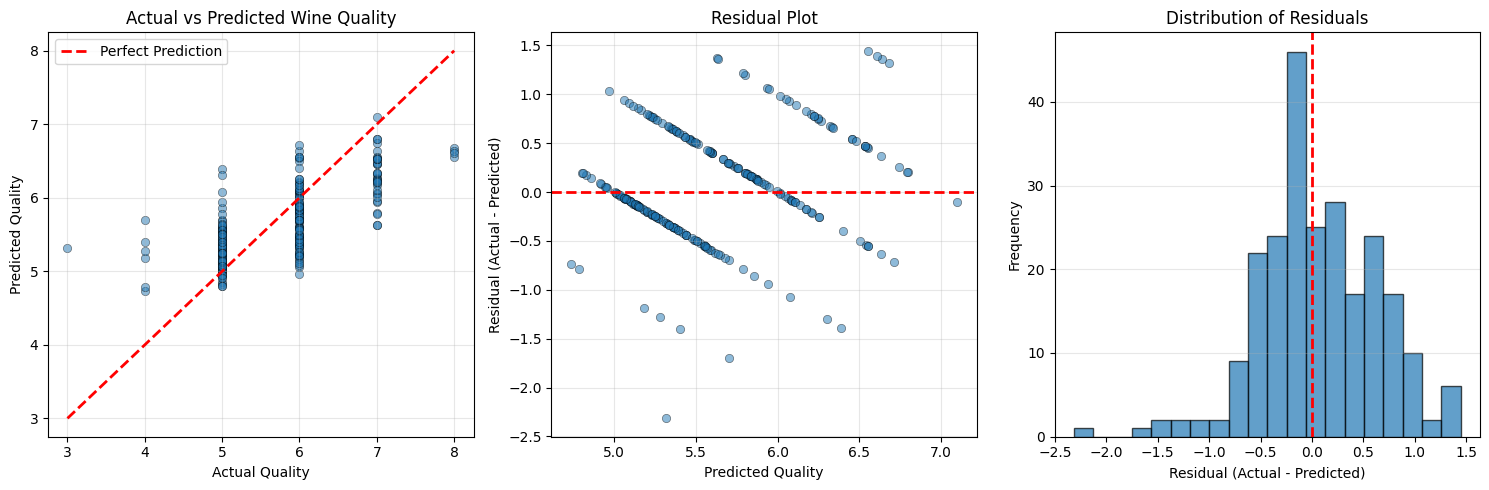


:bulb: Interpretation of plots:
   Plot 1: Points should cluster around the red line
   Plot 2: Points should scatter randomly around y=0 (no pattern)
   Plot 3: Should look roughly like a bell curve centered at 0


In [40]:
# Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, test_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Quality')
axes[0].set_ylabel('Predicted Quality')
axes[0].set_title('Actual vs Predicted Wine Quality')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test - test_pred
axes[1].scatter(test_pred, residuals, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Quality')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

# Plot 3: Residual Distribution
axes[2].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
axes[2].axvline(x=0, color='r', linestyle='--', lw=2)
axes[2].set_xlabel('Residual (Actual - Predicted)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Residuals')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n:bulb: Interpretation of plots:")
print("   Plot 1: Points should cluster around the red line")
print("   Plot 2: Points should scatter randomly around y=0 (no pattern)")
print("   Plot 3: Should look roughly like a bell curve centered at 0")